In [ ]:
import numpy as np, h5py, os
import matplotlib.pyplot as plt

BASE = "./"
k = 50  # number of PoIs to select
poi_save = "poi_idx.npy"

# Load full profiling traces + labels
with h5py.File("CHES_Challenge.h5", "r") as f:
    X_profile = f["Profiling_traces/traces"][:].astype(np.float32)
    y_profile = np.load("cache/y_train_int64.npy")  # already available

def compute_snr(traces, labels, num_classes=9):
    snr = np.zeros(traces.shape[1])
    for c in range(num_classes):
        class_traces = traces[labels == c]
        if len(class_traces) == 0: continue
        mean_c = np.mean(class_traces, axis=0)
        var_c  = np.var(class_traces, axis=0)
        mean_t = np.mean(traces, axis=0)
        snr += (mean_c - mean_t)**2 / (var_c + 1e-9)
    return snr

# Compute SNR and find PoIs
snr = compute_snr(X_profile, y_profile)
poi_idx = np.argsort(snr)[-k:]  # top k peaks (sorted ascending)

# Save indices
np.save(os.path.join(BASE, poi_save), poi_idx)
print(f"Saved top-{k} PoI indices to {poi_save}")

# Plot SNR with PoIs marked
plt.figure(figsize=(12,4))
plt.plot(snr, label="SNR")
plt.scatter(poi_idx, snr[poi_idx], color="red", label="Selected PoIs")
plt.title(f"SNR with top {k} PoIs marked")
plt.xlabel("Sample index")
plt.ylabel("SNR")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


In [3]:
import numpy as np, h5py, os

BASE = "./"                       # location of poi_idx.npy
w_new = 101                       # expanded window size
half_w = w_new // 2

poi_idx = np.load(os.path.join(BASE, "poi_idx.npy"))  # load PoIs

# Load full profiling and attack traces
with h5py.File("CHES_Challenge.h5", "r") as f:
    X_profile = f["Profiling_traces/traces"][:].astype(np.float32)
    X_attack  = f["Attack_traces/traces"][:].astype(np.float32)
    plains_attack = np.array(f["Attack_traces/metadata"]["plaintext"])

def slice_windows(traces, idx, half_w):
    pad = ((0,0),(half_w,half_w))
    t_pad = np.pad(traces, pad, mode="edge")
    windows = [t_pad[:, i:i+2*half_w+1] for i in idx]
    return np.concatenate(windows, axis=1)

# Slice windows for profiling and attack sets
X_profile_crop = slice_windows(X_profile, poi_idx, half_w)
X_attack_crop  = slice_windows(X_attack, poi_idx, half_w)

print("New shapes:",
      "Profiling", X_profile_crop.shape,
      "Attack", X_attack_crop.shape)

# Save new cache
os.makedirs("cache_wide", exist_ok=True)
np.save("cache_wide/X_train_fp32.npy", X_profile_crop)
np.save("cache_wide/X_attack_fp32.npy", X_attack_crop)
np.save("cache_wide/plains_attack_u8.npy", plains_attack)

print("Saved re-cropped traces in cache_wide/")


New shapes: Profiling (500000, 5050) Attack (100000, 5050)
Saved re-cropped traces in cache_wide/


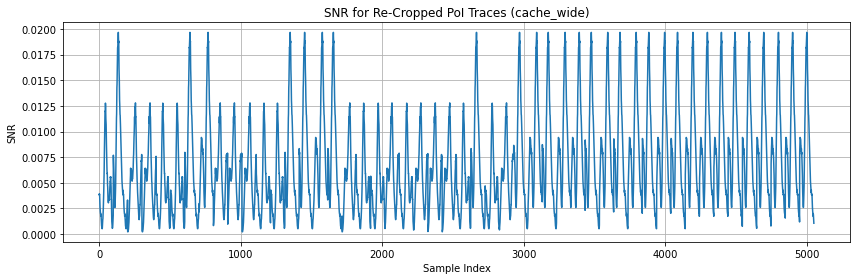

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load the new cropped profiling traces and labels
X_train = np.load("cache_wide/X_train_fp32.npy", mmap_mode="r")
y_train = np.load("cache/y_train_int64.npy", mmap_mode="r")  # labels are same

def compute_snr(traces, labels, num_classes=9):
    snr = np.zeros(traces.shape[1])
    for c in range(num_classes):
        class_traces = traces[labels == c]
        if len(class_traces) == 0:
            continue
        mean_c = np.mean(class_traces, axis=0)
        var_c = np.var(class_traces, axis=0)
        mean_t = np.mean(traces, axis=0)
        snr += (mean_c - mean_t)**2 / (var_c + 1e-9)
    return snr

# Compute SNR for the re-cropped set
snr_new = compute_snr(X_train, y_train)

# Plot SNR
plt.figure(figsize=(12,4))
plt.plot(snr_new)
plt.title("SNR for Re-Cropped PoI Traces (cache_wide)")
plt.xlabel("Sample Index")
plt.ylabel("SNR")
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
import h5py, numpy as np
from scipy.signal import find_peaks

def quadrant_scan_light(trace, window=512, step=256, alpha=0.05):
    """Memory-friendly approximation of Weighted Quadrant Scan for a single trace."""
    N = len(trace)
    QS_vals = np.zeros(N)

    for start in range(0, N - window, step):
        seg = trace[start:start+window]
        # Use variance + cross-correlation between halves as a proxy for transition strength
        var_left = np.var(seg[:window//2])
        var_right = np.var(seg[window//2:])
        corr = np.corrcoef(seg[:window//2], seg[window//2:])[0,1]
        score = (var_left + var_right) * (1 - corr)  # Higher when halves differ
        QS_vals[start+window//2] = score

    # Normalize
    QS_vals /= np.max(QS_vals) + 1e-12
    return QS_vals

# ---- Apply to 5 random profiling traces ---- #

with h5py.File("CHES_Challenge.h5", "r") as f:
    X_profile = f["Profiling_traces/traces"][:].astype(np.float32)  # (N, 7000)

# Pick 5 random traces
np.random.seed(42)
idx = np.random.choice(X_profile.shape[0], 5, replace=False)
sample_traces = X_profile[idx]

all_pois = []
for i, trace in enumerate(sample_traces):
    QS_scores = quadrant_scan_light(trace, window=512, step=128, alpha=0.05)
    # Find peaks (transition points)
    peaks, _ = find_peaks(QS_scores, distance=5)
    # Keep top 500 PoIs for each trace
    top_k = min(500, len(peaks))
    top_pois = peaks[np.argsort(QS_scores[peaks])[-top_k:]]
    all_pois.append(top_pois)
    print(f"Trace {i+1}: Found {len(top_pois)} PoIs")

# Save PoIs for all 5 traces
np.save("poi_indices_5traces.npy", np.array(all_pois, dtype=object))
print("Saved PoIs for 5 traces → poi_indices_5traces.npy")


Trace 1: Found 51 PoIs
Trace 2: Found 51 PoIs
Trace 3: Found 51 PoIs
Trace 4: Found 51 PoIs
Trace 5: Found 51 PoIs
Saved PoIs for 5 traces → poi_indices_5traces.npy


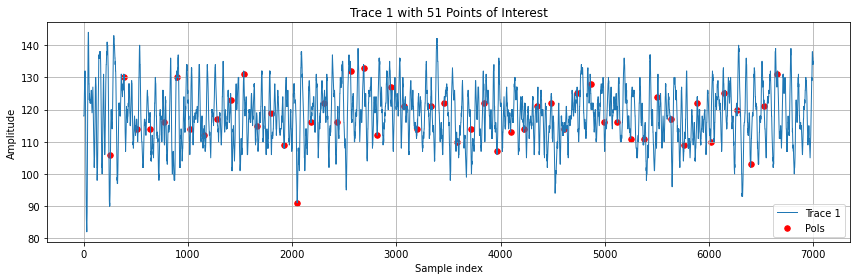

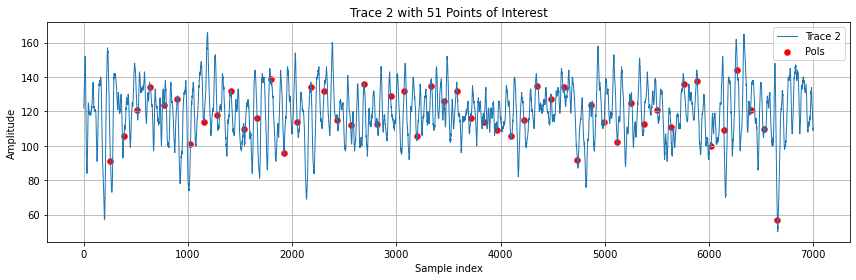

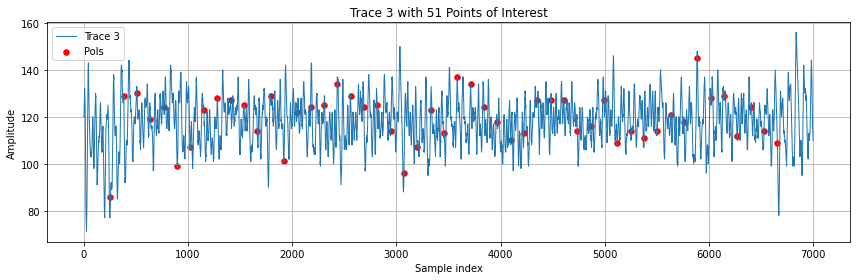

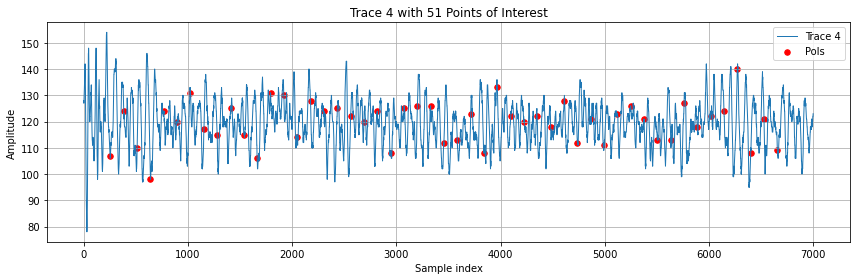

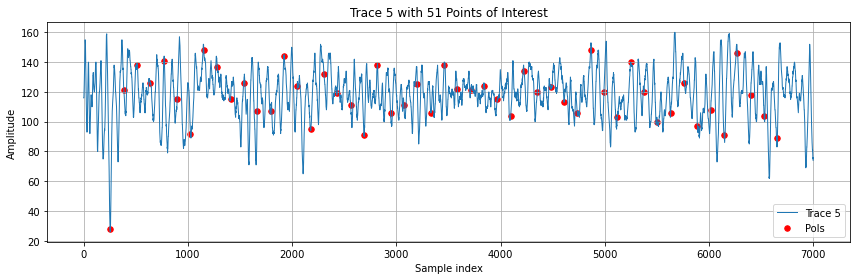

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Load saved PoIs (convert each list to int array)
poi_indices = np.load("poi_indices_5traces.npy", allow_pickle=True)
poi_indices = [np.array(pois, dtype=int) for pois in poi_indices]

# Load the same 5 traces used for PoI extraction
with h5py.File("CHES_Challenge.h5", "r") as f:
    X_profile = f["Profiling_traces/traces"][:].astype(np.float32)

np.random.seed(42)
idx = np.random.choice(X_profile.shape[0], 5, replace=False)
sample_traces = X_profile[idx]

# Plot each trace with its PoIs
for i, trace in enumerate(sample_traces):
    plt.figure(figsize=(12, 4))
    plt.plot(trace, label=f"Trace {i+1}", linewidth=1)
    plt.scatter(poi_indices[i], trace[poi_indices[i]], color="red", s=30, label="PoIs")
    plt.title(f"Trace {i+1} with {len(poi_indices[i])} Points of Interest")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


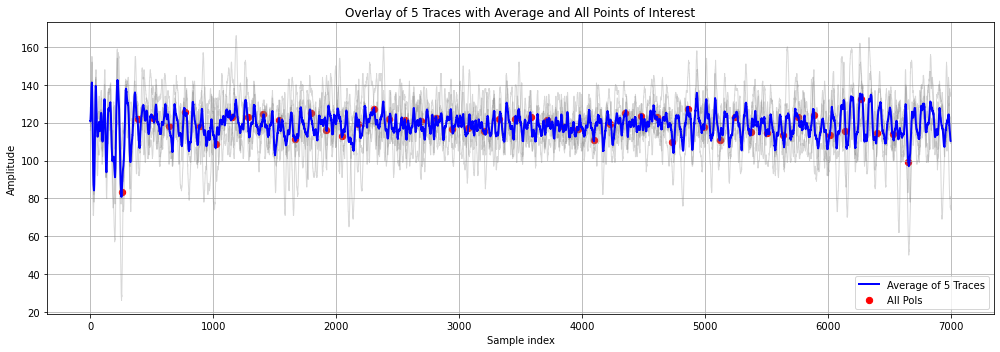

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Load PoIs (ensure integer arrays)
poi_indices = np.load("poi_indices_5traces.npy", allow_pickle=True)
poi_indices = [np.array(pois, dtype=int) for pois in poi_indices]

# Load the same 5 traces used for PoI extraction
with h5py.File("CHES_Challenge.h5", "r") as f:
    X_profile = f["Profiling_traces/traces"][:].astype(np.float32)

np.random.seed(42)
idx = np.random.choice(X_profile.shape[0], 5, replace=False)
sample_traces = X_profile[idx]

# Compute average trace
avg_trace = np.mean(sample_traces, axis=0)

# Combine all PoIs into one array (remove duplicates and sort)
all_pois = np.unique(np.concatenate(poi_indices))

# Plot all 5 traces (light lines), average trace (bold), and PoIs (red dots)
plt.figure(figsize=(14, 5))

# Plot all 5 traces as faint lines
for trace in sample_traces:
    plt.plot(trace, color='gray', alpha=0.3, linewidth=1)

# Plot average trace
plt.plot(avg_trace, color='blue', linewidth=2, label="Average of 5 Traces")

# Overlay PoIs on the average trace
plt.scatter(all_pois, avg_trace[all_pois], color="red", s=40, label="All PoIs")

plt.title("Overlay of 5 Traces with Average and All Points of Interest")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
# -*- coding: utf-8 -*-
"""
CHES 2025 Preprocessing (Hybrid SNR + HW Recurrence + Quadrant Scan)
- Uses challenge-provided HW labels (0–8) directly from metadata
- Combines SNR peaks, HW recurrence matrix, and Quadrant Scan filtering
- Adaptive PoI selection to fit VRAM (≤ TARGET_DIM samples)
- Crops profiling & attack traces, normalizes, applies PCA if large
- Saves arrays ready for training in `cache_hybrid/`
"""

SSSimport os, h5py, numpy as np, matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.decomposition import PCA

# ----------------- CONFIG -----------------
DATASET = "CHES_Challenge.h5"
OUTPUT_DIR = "cache_hybrid"
TOP_SNR = 120           # max SNR peaks before filtering
QS_WINDOW = 512
QS_STEP = 128
QS_THRESH = 0.5         # minimum QS score for PoIs
TARGET_DIM = 1024       # cap final cropped dimensionality (VRAM control)
WIN_LEN = 64            # per-window length
APPLY_PCA = True        # apply PCA if dim > 2000

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ----------------- LOAD DATA -----------------
print("[INFO] Loading dataset...")
with h5py.File(DATASET, "r") as f:
    Xp = f["Profiling_traces/traces"][:].astype(np.float32)
    Xa = f["Attack_traces/traces"][:].astype(np.float32)
    # labels are inside metadata (0–8 HW classes)
    Yp = f["Profiling_traces/metadata"]["labels"][:].astype(np.int64)
    plains_attack = f["Attack_traces/metadata"]["plaintext"][:, 0].astype(np.uint8)  # optional

# Optional HW recurrence matrix (per-sample importance for 0–8 classes)
HW_REC_FILE = "hw_recurrence.npy"
HW_REC = np.load(HW_REC_FILE) if os.path.exists(HW_REC_FILE) else None

# ----------------- METRIC FUNCTIONS -----------------
def compute_snr(traces, labels, num_classes=9):
    snr = np.zeros(traces.shape[1], dtype=np.float64)
    for c in range(num_classes):
        cls = traces[labels == c]
        if len(cls) == 0: continue
        mean_c, mean_tot = np.mean(cls, 0), np.mean(traces, 0)
        var_c = np.var(cls, 0)
        snr += (mean_c - mean_tot) ** 2 / (var_c + 1e-6)
    return snr

def quadrant_scan_light(trace, window=QS_WINDOW, step=QS_STEP):
    N = len(trace)
    vals = np.zeros(N, dtype=np.float64)
    for start in range(0, N - window, step):
        seg = trace[start:start+window]
        v1, v2 = np.var(seg[:window//2]), np.var(seg[window//2:])
        corr = np.corrcoef(seg[:window//2], seg[window//2:])[0,1]
        vals[start + window//2] = (v1 + v2) * (1 - corr)
    vals /= np.max(vals) + 1e-12
    return vals

def normalize_zscore(arr):
    return (arr - arr.mean(1, keepdims=True)) / (arr.std(1, keepdims=True) + 1e-8)

def slice_windows(traces, idx, win_len=WIN_LEN):
    half = win_len // 2
    pad = ((0,0), (half,half))
    padded = np.pad(traces, pad, mode="edge")
    windows = [padded[:, i:i+win_len] for i in idx]
    return np.concatenate(windows, axis=1)

# ----------------- STEP 1: SNR -----------------
print("[INFO] Computing SNR and selecting peaks...")
snr_vals = compute_snr(Xp, Yp, num_classes=9)
snr_peaks, _ = find_peaks(snr_vals, distance=20)
snr_ranked = snr_peaks[np.argsort(snr_vals[snr_peaks])[-TOP_SNR:]]

# ----------------- STEP 2: Quadrant Scan + HW Recurrence -----------------
print("[INFO] Applying Quadrant Scan refinement...")
qs_scores = np.zeros_like(snr_vals, dtype=np.float64)
for _ in range(5):  # average QS over random traces
    trace = Xp[np.random.randint(0, Xp.shape[0])]
    qs_scores += quadrant_scan_light(trace)
qs_scores /= 5.0

pois = []
for poi in sorted(snr_ranked):
    window = np.arange(max(0, poi-128), min(len(qs_scores), poi+128))
    if np.max(qs_scores[window]) < QS_THRESH:
        continue
    if HW_REC is not None and HW_REC[poi] < np.percentile(HW_REC, 75):
        continue
    pois.append(poi)
pois = np.unique(pois)

# ----------------- STEP 3: Dimensionality Control -----------------
while len(pois) * WIN_LEN > TARGET_DIM and len(pois) > 1:
    worst = np.argmin(snr_vals[pois])
    pois = np.delete(pois, worst)

print(f"[INFO] Final {len(pois)} PoIs → Cropped dim = {len(pois) * WIN_LEN}")


[INFO] Loading dataset...
[INFO] Computing SNR and selecting peaks...
[INFO] Applying Quadrant Scan refinement...
[INFO] Final 16 PoIs → Cropped dim = 1024


[DONE] Preprocessed data saved to cache_hybrid


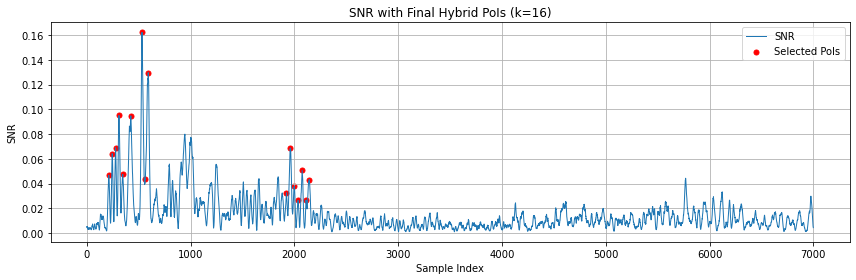

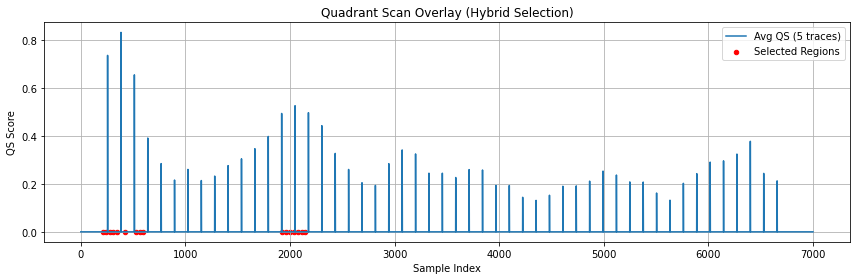

In [3]:
# ----------------- STEP 4: Crop & Normalize -----------------
Xp_crop, Xa_crop = slice_windows(Xp, pois), slice_windows(Xa, pois)
Xp_norm, Xa_norm = normalize_zscore(Xp_crop), normalize_zscore(Xa_crop)



# ----------------- SAVE -----------------
np.save(os.path.join(OUTPUT_DIR, "X_train_fp32.npy"), Xp_norm)
np.save(os.path.join(OUTPUT_DIR, "X_attack_fp32.npy"), Xa_norm)
np.save(os.path.join(OUTPUT_DIR, "y_train_int64.npy"), Yp)
np.save(os.path.join(OUTPUT_DIR, "plains_attack_u8.npy"), plains_attack)
np.save(os.path.join(OUTPUT_DIR, "poi_indices.npy"), pois)

print(f"[DONE] Preprocessed data saved to {OUTPUT_DIR}")

# ----------------- VISUALIZATION -----------------
plt.figure(figsize=(12,4))
plt.plot(snr_vals, label="SNR", linewidth=1)
plt.scatter(pois, snr_vals[pois], c="red", s=25, label="Selected PoIs")
plt.title(f"SNR with Final Hybrid PoIs (k={len(pois)})")
plt.xlabel("Sample Index"); plt.ylabel("SNR")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(qs_scores, label="Avg QS (5 traces)")
plt.scatter(pois, qs_scores[pois], c="red", s=20, label="Selected Regions")
plt.title("Quadrant Scan Overlay (Hybrid Selection)")
plt.xlabel("Sample Index"); plt.ylabel("QS Score")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()


In [4]:
# -*- coding: utf-8 -*-
"""
CHES 2025 Preprocessing (Hybrid PoIs → PCA)
- Targets 40 PoIs (≈ 2560 raw features before PCA)
- Uses SNR + Quadrant Scan + optional HW recurrence filtering
- Compresses to ≤1024 dimensions using PCA (99% variance)
- Outputs preprocessed arrays in `cache_hybrid/`
"""

import os, h5py, numpy as np, matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.decomposition import PCA

# ----------------- CONFIG -----------------
DATASET = "CHES_Challenge.h5"
OUTPUT_DIR = "cache_hybrid"
TOP_SNR = 200            # initial SNR peaks to consider
QS_WINDOW = 512
QS_STEP = 128
QS_THRESH = 0.5           # QS threshold for PoI acceptance
TARGET_POIS = 40          # target number of PoIs
WIN_LEN = 64              # per-window length
PCA_TARGET_DIM = 1024     # compress final dataset to ≤1024 dims
VARIANCE_KEEP = 0.99      # keep 99% variance in PCA

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ----------------- LOAD DATA -----------------
print("[INFO] Loading dataset...")
with h5py.File(DATASET, "r") as f:
    Xp = f["Profiling_traces/traces"][:].astype(np.float32)
    Xa = f["Attack_traces/traces"][:].astype(np.float32)
    Yp = f["Profiling_traces/metadata"]["labels"][:].astype(np.int64)
    plains_attack = f["Attack_traces/metadata"]["plaintext"][:,0].astype(np.uint8)


# ----------------- METRIC FUNCTIONS -----------------
def compute_snr(traces, labels, num_classes=9):
    snr = np.zeros(traces.shape[1], dtype=np.float64)
    for c in range(num_classes):
        cls = traces[labels == c]
        if len(cls) == 0: continue
        mean_c, mean_tot = np.mean(cls, 0), np.mean(traces, 0)
        var_c = np.var(cls, 0)
        snr += (mean_c - mean_tot) ** 2 / (var_c + 1e-6)
    return snr

def quadrant_scan_light(trace, window=QS_WINDOW, step=QS_STEP):
    N = len(trace)
    vals = np.zeros(N, dtype=np.float64)
    for start in range(0, N - window, step):
        seg = trace[start:start+window]
        v1, v2 = np.var(seg[:window//2]), np.var(seg[window//2:])
        corr = np.corrcoef(seg[:window//2], seg[window//2:])[0,1]
        vals[start + window//2] = (v1 + v2) * (1 - corr)
    vals /= np.max(vals) + 1e-12
    return vals

def normalize_zscore(arr):
    return (arr - arr.mean(1, keepdims=True)) / (arr.std(1, keepdims=True) + 1e-8)

def slice_windows(traces, idx, win_len=WIN_LEN):
    half = win_len // 2
    pad = ((0,0), (half,half))
    padded = np.pad(traces, pad, mode="edge")
    windows = [padded[:, i:i+win_len] for i in idx]
    return np.concatenate(windows, axis=1)



[INFO] Loading dataset...


In [5]:
# ----------------- STEP 1: Compute SNR -----------------
print("[INFO] Computing SNR...")
snr_vals = compute_snr(Xp, Yp)
snr_peaks, _ = find_peaks(snr_vals, distance=20)
ranked = snr_peaks[np.argsort(snr_vals[snr_peaks])[-TOP_SNR:]]

# ----------------- STEP 2: Quadrant Scan + HW Recurrence -----------------
print("[INFO] Applying Quadrant Scan...")
qs_scores = np.zeros_like(snr_vals, dtype=np.float64)
for _ in range(5):  # average over 5 traces
    trace = Xp[np.random.randint(0, Xp.shape[0])]
    qs_scores += quadrant_scan_light(trace)
qs_scores /= 5.0

pois = []
for poi in sorted(ranked):
    region = np.arange(max(0, poi-128), min(len(qs_scores), poi+128))
    if np.max(qs_scores[region]) < QS_THRESH:
        continue
    if HW_REC is not None and HW_REC[poi] < np.percentile(HW_REC, 75):
        continue
    pois.append(poi)
pois = np.unique(pois)



[INFO] Computing SNR...
[INFO] Applying Quadrant Scan...


[INFO] Final PoIs: 40 → Raw dim = 2560
[INFO] Applying PCA to ≤1024 dims (99% variance)...
[INFO] PCA output dim: 1024
[DONE] Saved PCA-compressed data to cache_hybrid


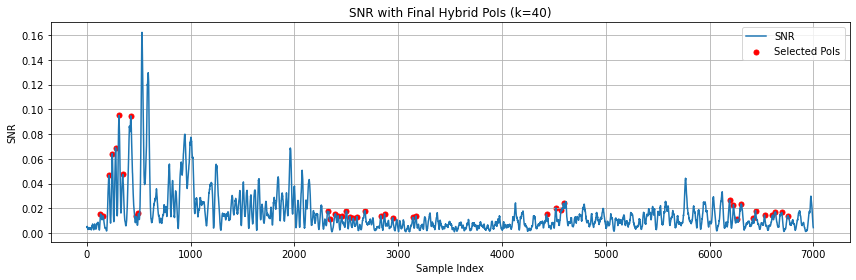

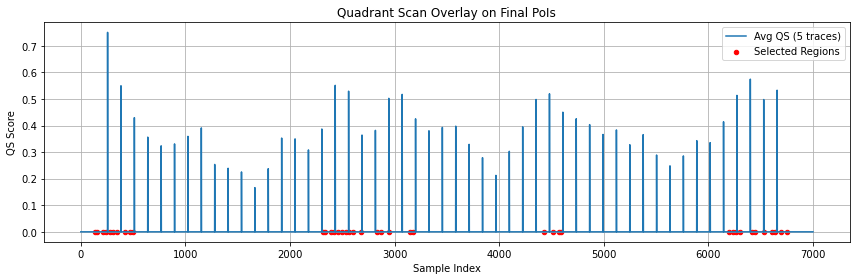

In [6]:
# ----------------- STEP 3: Limit to 40 PoIs -----------------
while len(pois) > TARGET_POIS:
    worst = np.argmin(snr_vals[pois])  # prune least SNR-significant
    pois = np.delete(pois, worst)

raw_dim = len(pois) * WIN_LEN
print(f"[INFO] Final PoIs: {len(pois)} → Raw dim = {raw_dim}")

# ----------------- STEP 4: Crop & Normalize -----------------
Xp_crop, Xa_crop = slice_windows(Xp, pois), slice_windows(Xa, pois)
Xp_norm, Xa_norm = normalize_zscore(Xp_crop), normalize_zscore(Xa_crop)

# ----------------- STEP 5: PCA Compression -----------------
print(f"[INFO] Applying PCA to ≤{PCA_TARGET_DIM} dims (99% variance)...")
pca = PCA(n_components=min(PCA_TARGET_DIM, Xp_norm.shape[1]), svd_solver="full")
Xp_pca = pca.fit_transform(Xp_norm)
Xa_pca = pca.transform(Xa_norm)
print(f"[INFO] PCA output dim: {Xp_pca.shape[1]}")

# ----------------- SAVE -----------------
np.save(os.path.join(OUTPUT_DIR, "X_train_fp32.npy"), Xp_pca)
np.save(os.path.join(OUTPUT_DIR, "X_attack_fp32.npy"), Xa_pca)
np.save(os.path.join(OUTPUT_DIR, "y_train_int64.npy"), Yp)
np.save(os.path.join(OUTPUT_DIR, "plains_attack_u8.npy"), plains_attack)
np.save(os.path.join(OUTPUT_DIR, "poi_indices.npy"), pois)

print(f"[DONE] Saved PCA-compressed data to {OUTPUT_DIR}")

# ----------------- VISUALIZATION -----------------
plt.figure(figsize=(12,4))
plt.plot(snr_vals, label="SNR")
plt.scatter(pois, snr_vals[pois], c="red", s=25, label="Selected PoIs")
plt.title(f"SNR with Final Hybrid PoIs (k={len(pois)})")
plt.xlabel("Sample Index"); plt.ylabel("SNR")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(qs_scores, label="Avg QS (5 traces)")
plt.scatter(pois, qs_scores[pois], c="red", s=20, label="Selected Regions")
plt.title("Quadrant Scan Overlay on Final PoIs")
plt.xlabel("Sample Index"); plt.ylabel("QS Score")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()
